In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

# Load the dataset
file_path = '/content/cleaned_nutrition_dataset[1].csv'
df = pd.read_csv(file_path)

In [ ]:
# Display basic info
print("Dataset Shape:", df.shape)
print("\nInitial Columns:\n", df.columns)
print("\nInitial Missing Values:\n", df.isnull().sum())
print("\nSample Data:\n", df.head())


Dataset Shape: (3454, 13)

Initial Columns:
 Index(['Vitamin C', 'Vitamin B11', 'Sodium', 'Calcium', 'Carbohydrates',
       'food', 'Iron', 'Caloric Value', 'Sugars', 'Dietary Fiber', 'Fat',
       'Protein', 'food_normalized'],
      dtype='object')

Initial Missing Values:
 Vitamin C          0
Vitamin B11        0
Sodium             0
Calcium            0
Carbohydrates      0
food               0
Iron               0
Caloric Value      0
Sugars             0
Dietary Fiber      0
Fat                0
Protein            0
food_normalized    0
dtype: int64

Sample Data:
    Vitamin C  Vitamin B11  Sodium  Calcium  Carbohydrates  \
0      0.082        0.086   0.018      2.8          0.073   
1      0.400        0.005   0.065     10.2          3.700   
2      0.000        0.000   0.000      0.0          0.000   
3      0.000        0.000   0.000      0.0          0.000   
4      0.000        0.000   0.000      0.0          0.000   

                     food   Iron  Caloric Value  Sugar

In [ ]:
# 1. Remove duplicates
initial_count = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"\nRemoved {initial_count - df.shape[0]} duplicate rows.")



Removed 0 duplicate rows.


In [ ]:
# 2. Handle missing values
missing_before = df.isnull().sum().sum()
df.dropna(thresh=int(0.7 * df.shape[1]), inplace=True)  # Drop rows with <70% non-null values
df.fillna(0, inplace=True)  # Fill remaining missing values with 0
missing_after = df.isnull().sum().sum()
print(f"Missing values before cleaning: {missing_before}, after cleaning: {missing_after}")

Missing values before cleaning: 0, after cleaning: 0


In [ ]:
# 3. Convert numeric columns where possible
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            continue


In [ ]:
# Summary stats
print("\nDescriptive Statistics:\n", df.describe())



Descriptive Statistics:
          Vitamin C  Vitamin B11        Sodium      Calcium  Carbohydrates  \
count  3454.000000  3454.000000   3454.000000  3454.000000    3454.000000   
mean      9.501021    11.447140    141.437806    53.953960      18.724570   
std      70.387542    33.849817    973.168394   103.339195      26.232674   
min       0.000000     0.000000      0.000000     0.000000       0.000000   
25%       0.000000     0.029000      0.057000     4.647500       1.700000   
50%       0.300000     0.075000      0.200000    21.940000       9.110000   
75%       5.382500     4.327500     21.372500    60.600000      26.400000   
max    3872.000000   550.520000  14174.590000  1283.500000     390.200000   

              Iron  Caloric Value       Sugars  Dietary Fiber          Fat  \
count  3454.000000    3454.000000  3454.000000    3454.000000  3454.000000   
mean      1.627954     227.591546     5.693513       2.157695    12.006807   
std       4.384574     336.277025    13.136356

In [ ]:
# Top 10 high-calorie items
if 'Calories' in df.columns:
    print("\nTop 10 High Calorie Foods:")
    print(df[['Calories']].sort_values(by='Calories', ascending=False).head(10))


    # Plot calorie distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Calories'], bins=30, kde=True, color='orange')
    plt.title('Calories Distribution')
    plt.xlabel('Calories')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



<ipython-input-16-83cadbd76835>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_protein['Protein'], y=top_protein.index, palette='viridis')


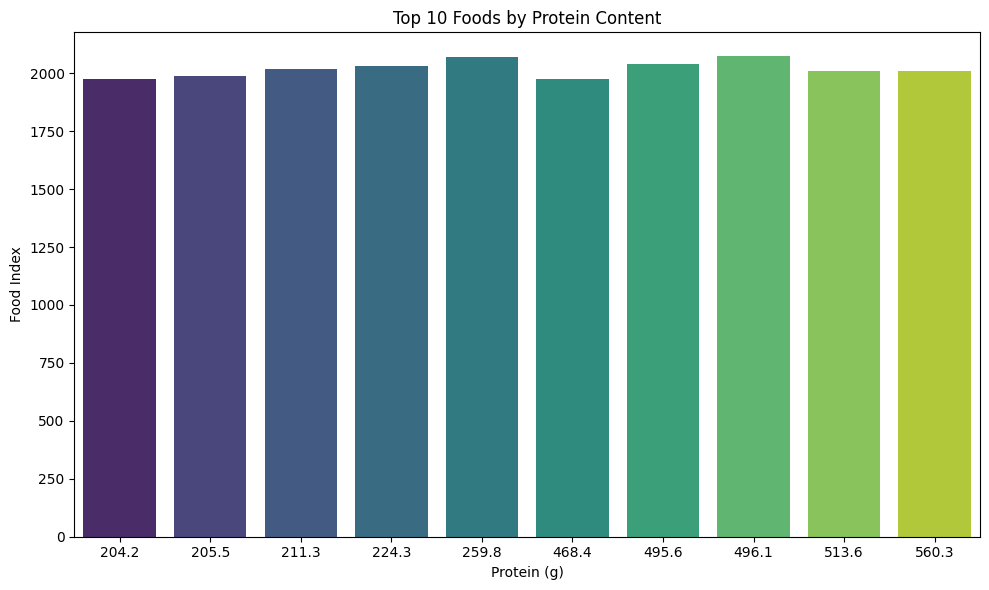

In [ ]:
# Bar Plot: Top 10 foods by Protein content
if 'Protein' in df.columns:
    top_protein = df[['Protein']].sort_values(by='Protein', ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_protein['Protein'], y=top_protein.index, palette='viridis')
    plt.title('Top 10 Foods by Protein Content')
    plt.xlabel('Protein (g)')
    plt.ylabel('Food Index')
    plt.tight_layout()
    plt.show()

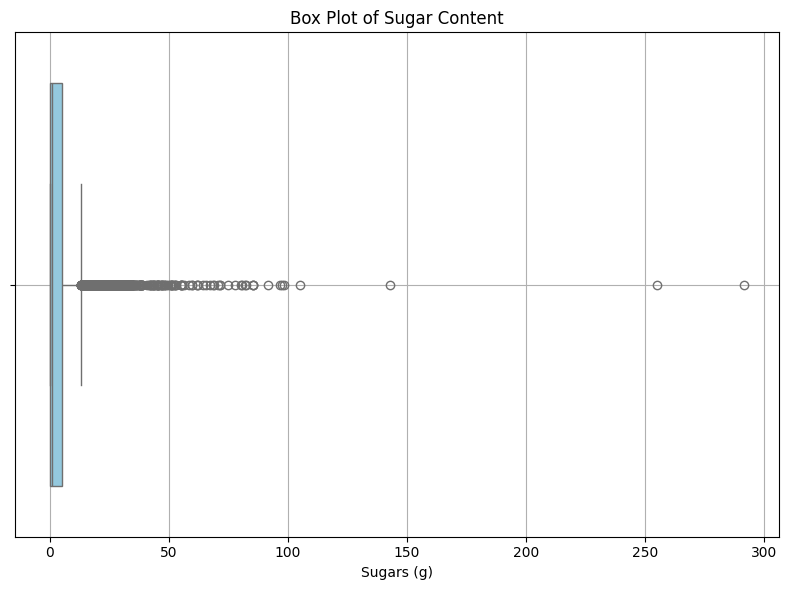

In [ ]:
# Box Plot: Distribution of Sugar content
if 'Sugars' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df['Sugars'], color='skyblue')
    plt.title('Box Plot of Sugar Content')
    plt.xlabel('Sugars (g)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

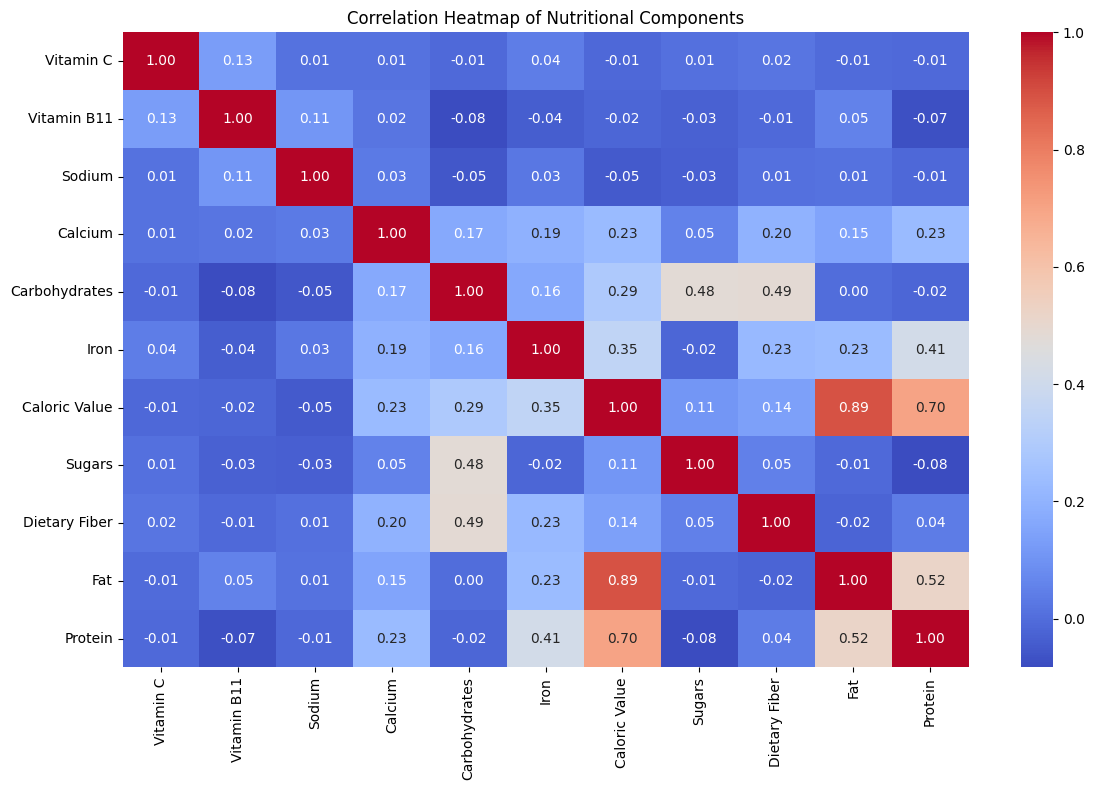

In [ ]:
# Heatmap: Correlation between numeric nutrients
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Nutritional Components')
plt.tight_layout()
plt.show()

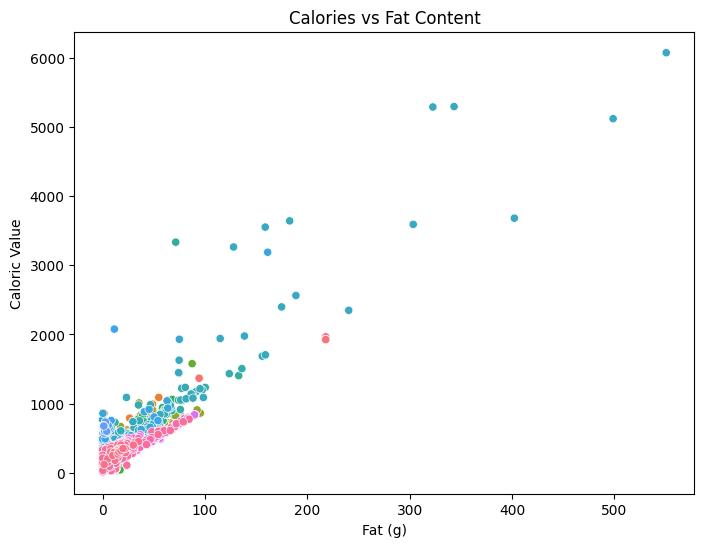

In [ ]:
# Scatter plot: Calories vs Fat
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Fat', y='Caloric Value', hue='food_normalized', legend=False)
plt.title('Calories vs Fat Content')
plt.xlabel('Fat (g)')
plt.ylabel('Caloric Value')
plt.show()

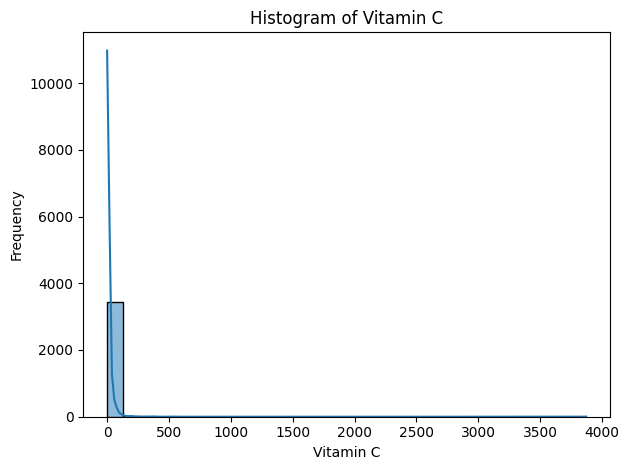

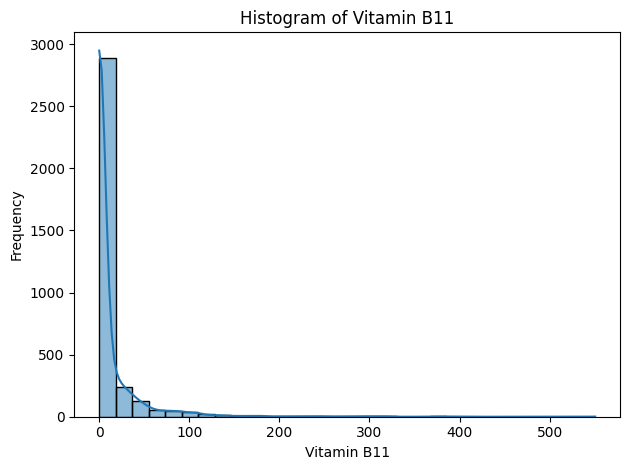

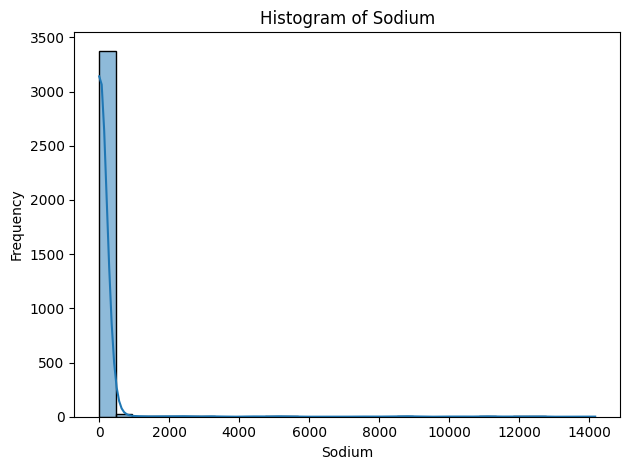

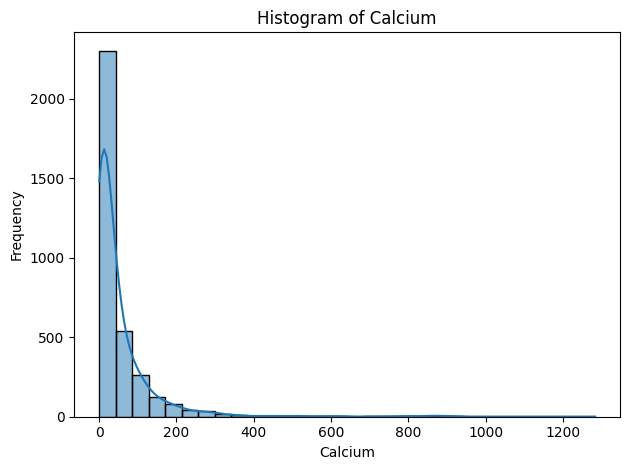

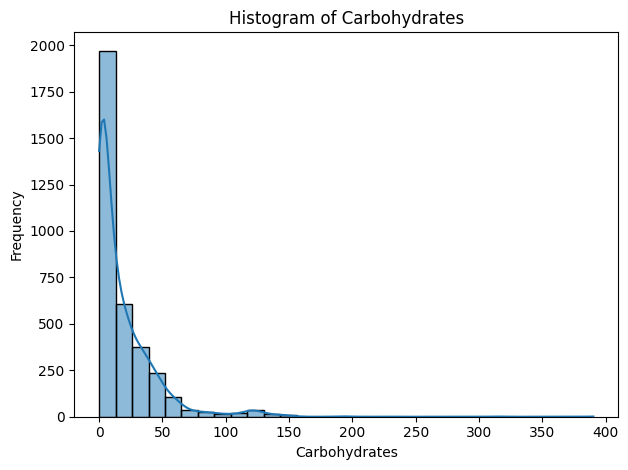

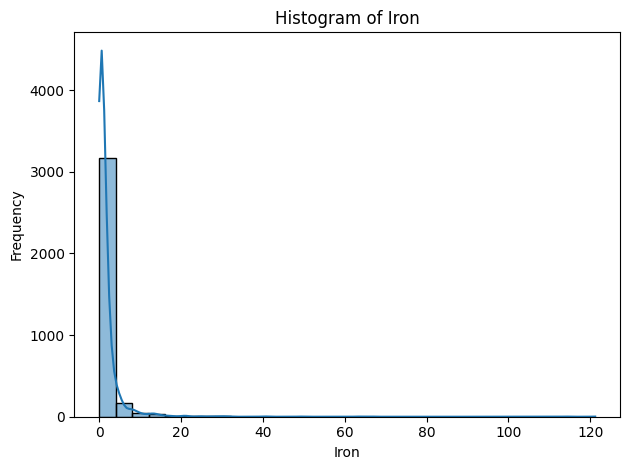

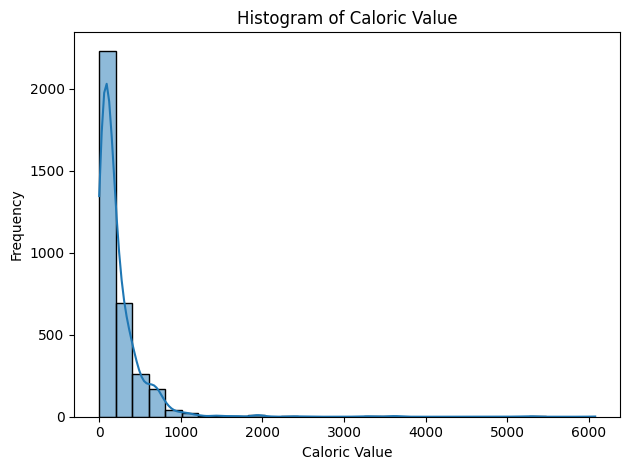

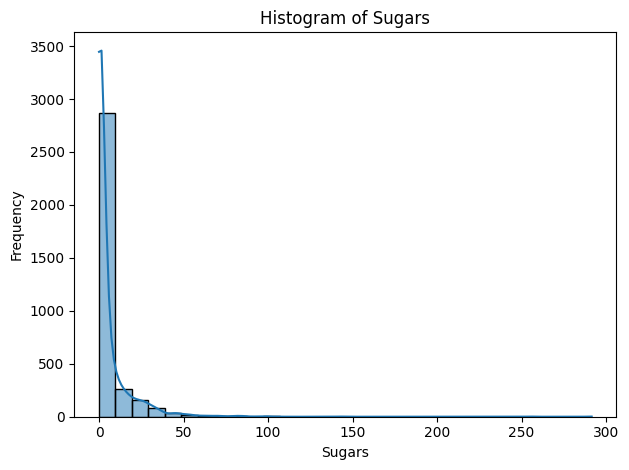

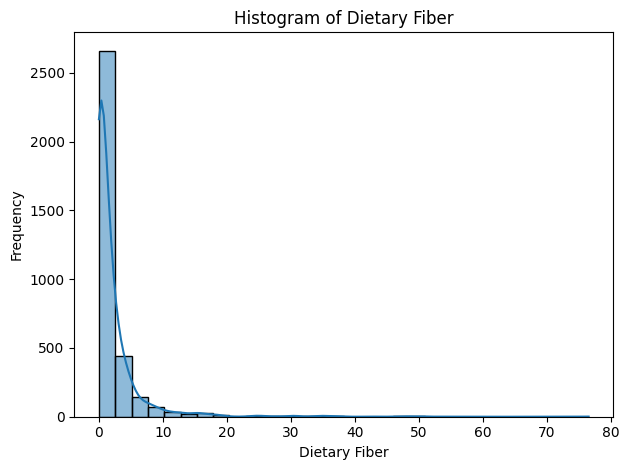

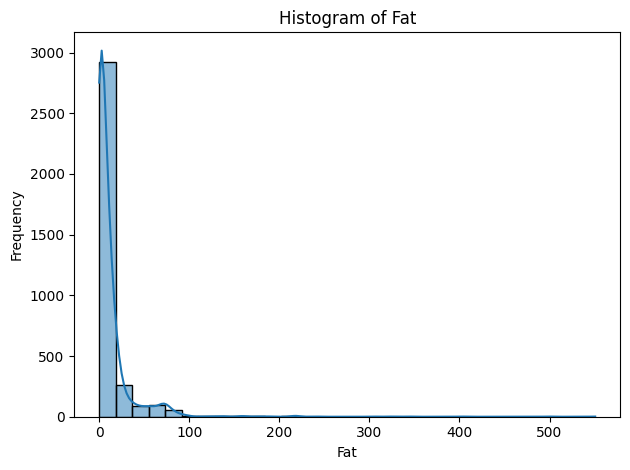

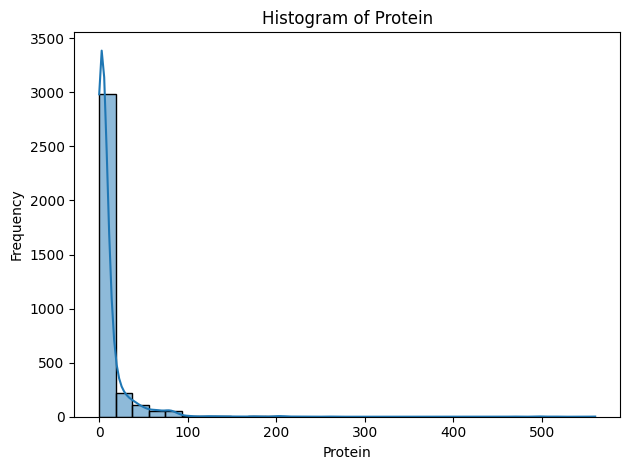

In [ ]:
# Histograms for all numeric features
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()